# 01 — Figura, ejes y anatomía del gráfico

En matplotlib todo vive dentro de una `Figure`. Una figura puede contener uno o varios `Axes` (subgráficos). Entender esta jerarquía es lo que permite controlar cada elemento del gráfico con precisión.

## Setup

`%matplotlib inline` activa el backend de ipympl — renderiza los gráficos como widgets interactivos dentro del notebook sin depender del backend nativo del sistema.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root():
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / 'data').exists():
            return parent

ROOT  = find_project_root()
TRAIN = ROOT / 'data' / 'external' / 'train.csv'
AIR   = ROOT / 'data' / 'external' / 'Listings.csv'


## La jerarquía de objetos

```
Figure          — el lienzo completo
└── Axes        — el área de dibujo (un "subgráfico")
    ├── Title
    ├── XAxis  →  XLabel, XTicks
    ├── YAxis  →  YLabel, YTicks
    ├── Line2D / Patch / ... (los datos)
    └── Legend
```

Esta separación permite modificar cualquier elemento de forma independiente.

## `plt.subplots()` — la forma estándar

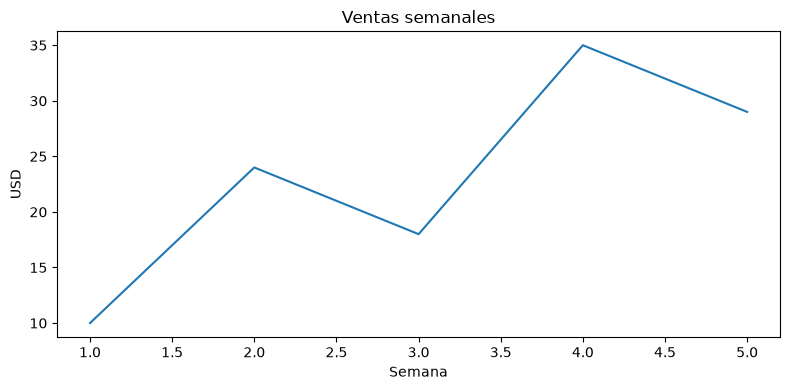

In [2]:
# fig es la Figure, ax es el Axes
fig, ax = plt.subplots(figsize=(8, 4))

x = [1, 2, 3, 4, 5]
y = [10, 24, 18, 35, 29]

ax.plot(x, y)

ax.set_title('Ventas semanales')
ax.set_xlabel('Semana')
ax.set_ylabel('USD')

plt.tight_layout()
plt.show()


## Anatomía completa — etiquetar cada parte

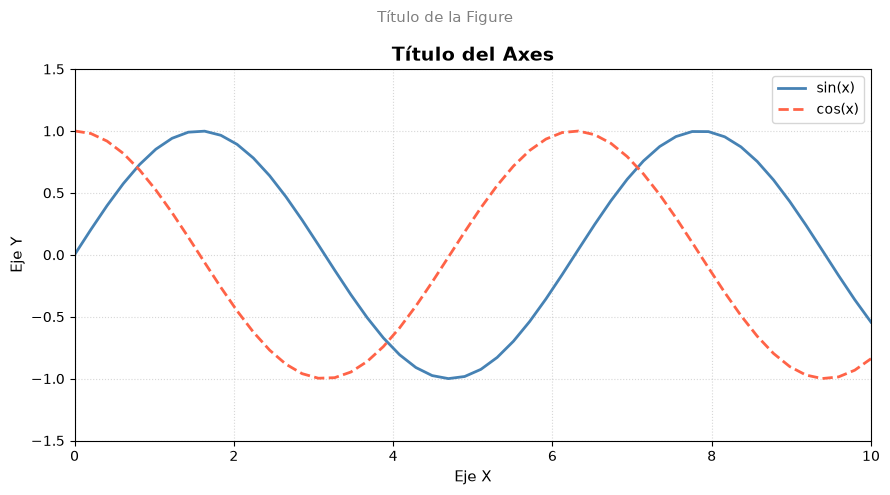

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.linspace(0, 10, 50)
ax.plot(x, np.sin(x), color='steelblue', linewidth=2, label='sin(x)')
ax.plot(x, np.cos(x), color='tomato',    linewidth=2, label='cos(x)', linestyle='--')

# Título del gráfico y de la figura
ax.set_title('Título del Axes', fontsize=14, fontweight='bold')
fig.suptitle('Título de la Figure', fontsize=11, color='gray')

# Etiquetas de ejes
ax.set_xlabel('Eje X', fontsize=11)
ax.set_ylabel('Eje Y', fontsize=11)

# Límites manuales
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

# Grid y leyenda
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


## Diferenciar `plt.*` vs `ax.*`

Hay dos formas de hacer casi lo mismo en matplotlib:

| Forma | Sintaxis | Cuándo usarla |
|-------|----------|---------------|
| **Orientada a objetos** | `ax.set_title(...)` | Siempre que haya más de un Axes, o para código profesional |
| **Stateful (pyplot)** | `plt.title(...)` | Solo para gráficos rápidos de una sola figura |

La forma orientada a objetos (`ax.método`) es la correcta para cualquier código que vaya más allá de un prototipo rápido.

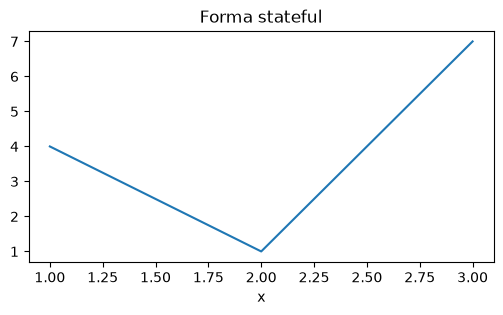

In [4]:
# Forma stateful (pyplot) — aplica al Axes 'activo'
plt.figure(figsize=(6, 3))
plt.plot([1, 2, 3], [4, 1, 7])
plt.title('Forma stateful')
plt.xlabel('x')
plt.show()


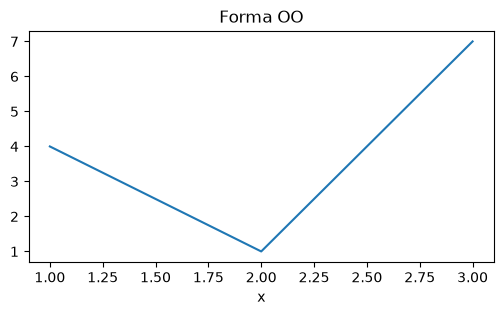

In [5]:
# Forma orientada a objetos — explicita, predecible
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3], [4, 1, 7])
ax.set_title('Forma OO')
ax.set_xlabel('x')
plt.show()


---
## Resumen

| Concepto | Descripción |
|----------|-------------|
| `Figure` | El lienzo completo |
| `Axes` | Un área de dibujo dentro de la figura |
| `plt.subplots(figsize)` | Crea figura + axes en una línea |
| `ax.set_title/xlabel/ylabel` | Etiquetas del gráfico |
| `ax.set_xlim/ylim` | Límites de los ejes |
| `ax.grid()` | Grilla de fondo |
| `ax.legend()` | Leyenda |
| `plt.tight_layout()` | Ajusta márgenes automáticamente |
